In [54]:
import numpy as np
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

In [211]:
def generate_costs(n, var=0.1): 
    return np.random.rand(n,n) 
    # costs = np.zeros((n,n)) 
    # for i in range(n): 
    #     for k in range(n): 
    #         costs[i,k] = np.maximum(1 + np.abs(i-k) + np.random.randn() * var, 0) 
    # for i in range(n): costs[i,i] = n 
    return costs 

In [212]:
def solve_greedy(costs): 
    n = len(costs) 

    all_costs = [(costs[i,j], i, j) for i in range(n) for j in range(n)] 

    sorted_costs = sorted(all_costs)

    chosen_a = [] 
    chosen_b = [] 
    ans = 0
    chosen_costs = []
    for edge in sorted_costs: 
        c, a, b = edge 
        if a in chosen_a or b in chosen_b: continue 
        chosen_a.append(a) 
        chosen_b.append(b) 
        ans += c 
        chosen_costs.append(c)
        if len(chosen_a) == n: break 
    return ans, chosen_costs  

In [213]:
def optimal_solution(costs): 
    a, b = linear_sum_assignment(costs)
    return costs[a, b].sum()

In [239]:
var = 1

greedy_costs = [] 
optimal_costs = []
ns = [2, 10, 100, 200, 300, 400, 500, 600, 700]
for n in ns:
    greedy_cur= [] 
    optimal_cur = []

    for _ in range(10):
        costs = generate_costs(n, var)
        # costs = np.random.rand(n,n)
        cost, chosen = solve_greedy(costs)
        optimal = optimal_solution(costs)

        greedy_cur.append(cost)
        optimal_cur.append(optimal)

    greedy_costs.append(np.mean(greedy_cur))
    optimal_costs.append(np.mean(optimal_cur))

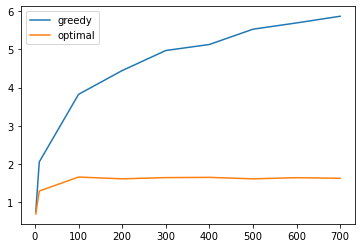

In [240]:
plt.plot(ns, greedy_costs, label='greedy')
plt.plot(ns, optimal_costs, label='optimal')
plt.legend()

In [255]:
np.sum([1 / (n**2 - k*n + 1) for k in range(1,n+1)])

1.0000143927240779

In [207]:
greedy_costs = []
optimal_costs = []

n = 200
var = 0.5 
for t in range(100):
    print(t)
    costs = generate_costs(n, var)
    # costs = np.random.rand(n,n)
    cost, chosen = solve_greedy(costs)
    optimal = optimal_solution(costs)

    greedy_costs.append(cost)
    optimal_costs.append(optimal) 

    print(np.mean(greedy_costs), np.mean(optimal_costs)) 

0
559.9889579803879 373.8673710624515
1
503.61297482266536 373.7323839263328
2
501.6887542760854 375.33267941227064
3
489.0078249003806 376.4333669710269
4
548.4266899799411 376.04690882244756
5
564.5641711518618 376.0757666055547
6
574.4239498340612 376.2902139686492
7
565.4199195581582 375.79183303896576
8
574.3199957440211 376.9083082130811
9
562.0263217354454 377.4149093948959
10
568.8070875183658 377.74213618310927
11
559.8214789120701 377.1850008269846
12
568.9537280109331 377.1898819779334
13
563.0258613178212 376.6741123672567
14
556.0461460997961 376.4714320468963
15
550.8008892029602 376.7539020723562
16
546.2343973545328 376.6316930500353
17
553.876025906548 376.6771771068904
18
553.3280816802719 376.8573252888196
19
550.6987439578199 377.1595546767436
20
561.7432721974429 377.11235354233503
21
564.409816936129 377.42454848918356
22
562.8746144985702 377.7010966131757
23
566.3285481881543 377.6112592356797
24
571.3568763276558 378.026568332896
25
572.5585467362373 377.996404

In [208]:
greedy_costs = np.array(greedy_costs)
optimal_costs = np.array(optimal_costs)

In [221]:
all_costs = [(costs[i,j], i, j) for i in range(n) for j in range(n)] 
sorted_costs = sorted(all_costs)